In [2]:
import pandas as pd

def parse_option_chain(file_path):
    # Step 1: Read raw CSV (skip top junk rows)
    df = pd.read_csv(file_path, skiprows=1)

    # Step 2: Drop completely empty columns
    df = df.dropna(axis=1, how='all')

    # Step 3: Rename columns manually (based on NSE format)
    df.columns = [
        "Call_OI", "Call_OI_Change", "Call_Volume", "Call_IV",
        "Call_LTP", "Call_Change", "Call_Bid_Qty", "Call_Bid",
        "Call_Ask", "Call_Ask_Qty",
        "Strike",
        "Put_Bid_Qty", "Put_Bid", "Put_Ask", "Put_Ask_Qty",
        "Put_Change", "Put_LTP", "Put_IV", "Put_Volume",
        "Put_OI_Change", "Put_OI"
    ]

    # Step 4: Remove rows where Strike is missing
    df = df[df["Strike"].notna()]

    # Step 5: Clean numeric columns (remove commas, '-')
    def clean_numeric(col):
        return (
            col.astype(str)
            .str.replace(',', '', regex=False)
            .replace('-', None)
        )

    for col in df.columns:
        df[col] = clean_numeric(df[col])

    # Step 6: Convert to numeric
    df = df.apply(pd.to_numeric, errors='ignore')

    return df


# ---- Usage ----
file_path = "option-chain-ED-NIFTY-30-Mar-2026.csv"
option_df = parse_option_chain(file_path)

print(option_df)

     Call_OI  Call_OI_Change  Call_Volume  Call_IV  Call_LTP  Call_Change  \
0     2568.0             8.0         29.0      NaN   4120.85        60.60   
1     1244.0          -104.0        313.0      NaN   3148.45       131.10   
2        NaN             NaN          NaN      NaN       NaN          NaN   
3        NaN             NaN          NaN      NaN       NaN          NaN   
4        3.0             NaN          NaN      NaN   2537.65         4.20   
..       ...             ...          ...      ...       ...          ...   
146    238.0          -193.0        356.0    39.73      0.90        -0.40   
147   2081.0          -163.0        542.0    39.85      0.85        -0.25   
148  10567.0           -75.0        636.0    45.20      0.75        -0.20   
149   7311.0          -223.0        799.0    51.34      0.75        -0.15   
150   4450.0            77.0        691.0    56.88      0.70        -0.10   

     Call_Bid_Qty  Call_Bid  Call_Ask  Call_Ask_Qty  ...  Put_Bid_Qty  \
0 

/var/folders/b0/gc9ydrkd131ggp9zcr4zhmp00000gn/T/ipykernel_43905/3728558057.py:36: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [13]:
def split_calls_puts(df):
    call_cols = [col for col in df.columns if col.startswith("Call")] + ["Strike"]
    put_cols  = [col for col in df.columns if col.startswith("Put")] + ["Strike"]

    calls_df = df[call_cols].copy()
    puts_df  = df[put_cols].copy()

    return calls_df, puts_df


calls, puts = split_calls_puts(option_df)

calls.head()

,Call_OI,Call_OI_Change,Call_Volume,Call_IV,Call_LTP,Call_Change,Call_Bid_Qty,Call_Bid,Call_Ask,Call_Ask_Qty,Strike
0,2568.0,8.0,29.0,NaN,4120.85,60.6,65.0,4115.35,4142.70,65.0,19000.0
1,1244.0,-104.0,313.0,NaN,3148.45,131.1,195.0,3130.95,3151.25,65.0,20000.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20850.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2327.90,780.0,20900.0
4,3.0,NaN,NaN,NaN,2537.65,4.2,780.0,1749.75,2368.75,780.0,20950.0


In [14]:
puts.head()

,Put_Bid_Qty,Put_Bid,Put_Ask,Put_Ask_Qty,Put_Change,Put_LTP,Put_IV,Put_Volume,Put_OI_Change,Put_OI,Strike
0,195.0,5.10,5.40,390.0,-0.55,5.40,50.88,43156.0,4154.0,88647.0,19000.0
1,195.0,13.10,13.20,585.0,-4.80,13.10,44.37,60410.0,4679.0,80474.0,20000.0
2,65.0,21.50,22.90,650.0,-8.00,22.50,36.88,13971.0,4026.0,5541.0,20850.0
3,975.0,22.40,25.30,65.0,4.10,24.15,36.69,5081.0,1198.0,1201.0,20900.0
4,195.0,24.65,25.75,260.0,-7.90,25.15,36.28,8220.0,167.0,5295.0,20950.0


In [16]:
def put_call_ratio(calls, puts):
    total_call_oi = calls['Call_OI'].sum()
    total_put_oi = puts['Put_OI'].sum()
    
    if total_call_oi == 0:
        return float('inf')  # Avoid division by zero
    return total_put_oi / total_call_oi

def pcr_interpretation(pcr):
    if pcr > 1:
        return "Bearish sentiment (more puts than calls)"
    elif pcr < 1:
        return "Bullish sentiment (more calls than puts)"
    else:
        return "Neutral sentiment (equal puts and calls)"

pcr = put_call_ratio(calls, puts)
print(f"Put-Call Ratio (PCR): {pcr:.2f}")
print(pcr_interpretation(pcr))

Put-Call Ratio (PCR): 1.08
Bearish sentiment (more puts than calls)


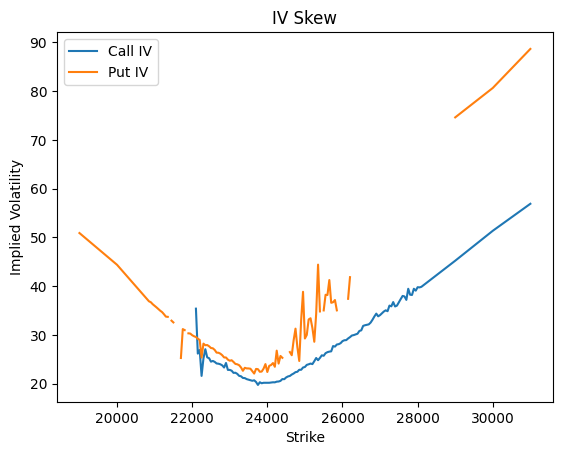

In [22]:
import matplotlib.pyplot as plt

# Plot IV vs Strike
plt.plot(option_df["Strike"], option_df["Call_IV"], label="Call IV")
plt.plot(option_df["Strike"], option_df["Put_IV"], label="Put IV")

plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("IV Skew")
plt.legend()
plt.show()